# 3.4 Using dandelion to study the consensus light chains

Author: Xuezhu Sunny Wang, Xinyi Xiong

## Dataset 📊

- scRNA-seq object of plasma cells
- The matching scBCR-seq files

## Steps overview 📒
- Use dandelion to compute the VDJ characteristics and isotype (chain_status,Extra pair,Orphan VDJ,Orphan VJ,Single pair)
- Align the full amino acid of light chain in each clonotype
- Plot the alignment heatmap and consensus light chain sequence of the amyloid clone


In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import Image
import scanpy as sc
import re
from types import SimpleNamespace 
import dandelion as ddl
from matplotlib import cm
from collections.abc import Sequence
from collections import Counter
from typing import Sequence
np.random.seed(14)


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/dandelion/lib/python3.10/site-packages/airr/schema.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/dandelion/lib/python3.10/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



In [2]:
# Step 1: read the mapping file
mapping = pd.read_csv("Sample-to-BCR_mapping.csv")

# Step 2: create dictionary to store vdj objects
vdj_dict = {}

# Step 3: iterate over rows in mapping file
for _, row in mapping.iterrows():
    sample_id = row["Sample_ID"]
    file_path = row["BCR_File_Path"]

    folder_location = os.path.dirname(file_path) + "/"

    # Load VDJ data
    vdj = ddl.read_10x_vdj(folder_location, filename_prefix="filtered")

    # Add prefix to ensure unique barcodes
    vdj.add_cell_prefix(f"{sample_id}_")

    vdj_dict[sample_id] = vdj

# Merge all objects into one
vdj_merged = ddl.concat(list(vdj_dict.values()))

# Example: inspect merged object
print(vdj_merged)


Dandelion class object with n_obs = 290737 and n_contigs = 456154
    data: 'cell_id', 'is_cell_10x', 'sequence_id', 'high_confidence_10x', 'sequence_length_10x', 'locus', 'v_call', 'd_call', 'j_call', 'c_call', 'complete_vdj', 'productive', 'fwr1_aa', 'fwr1', 'cdr1_aa', 'cdr1', 'fwr2_aa', 'fwr2', 'cdr2_aa', 'cdr2', 'fwr3_aa', 'fwr3', 'junction_aa', 'junction', 'fwr4_aa', 'fwr4', 'consensus_count', 'umi_count', 'clone_id', 'raw_consensus_id_10x', 'exact_subclonotype_id_10x', 'rearrangement_status', 'sequence', 'sequence_aa', 'vj_in_frame', 'cdr3_start', 'cdr3_end', 'fwr1_start', 'fwr1_end', 'cdr1_start', 'cdr1_end', 'fwr2_start', 'fwr2_end', 'cdr2_start', 'cdr2_end', 'fwr3_start', 'fwr3_end', 'fwr4_start', 'fwr4_end', 'filtered_10x', 'is_asm_cell_10x'
    metadata: 'clone_id', 'clone_id_by_size', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junct

In [3]:
# --- Load data
adata = sc.read_h5ad("counts_clean_modified.h5ad")  # used to be the plasma cell sample

# Replace "MM" with "HPCAL" in all cell barcodes
adata.obs_names = adata.obs_names.str.replace("MM", "HPCAL", regex=False)

vdj, adata = ddl.pp.check_contigs(vdj_merged, adata)


Preparing data: 408696it [01:12, 5646.31it/s]
Scanning for poor quality/ambiguous contigs: 100%|██████████| 266127/266127 [13:19<00:00, 332.81it/s]


In [4]:
pd.crosstab(adata.obs["has_contig"], adata.obs["chain_status"])


chain_status,Extra pair,Orphan VDJ,Orphan VJ,Single pair
has_contig,,,,
True,2407,3242,75449,100736


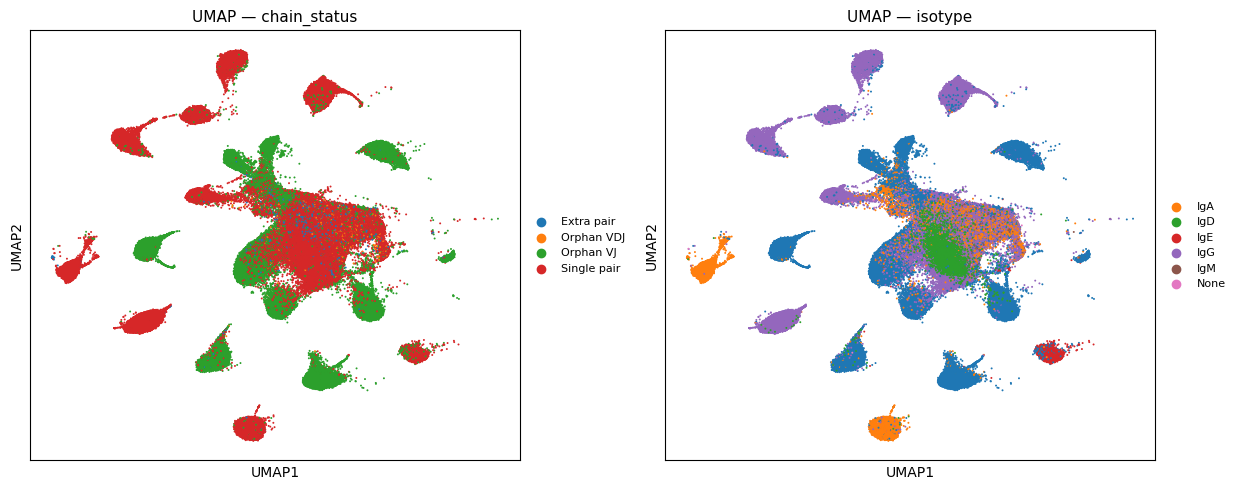

In [5]:
# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * figsize + figsize * wspace * (ncols - 1), nrows * figsize),
)
plt.subplots_adjust(wspace=wspace)

# --- Panel 1: clusters (leiden / seurat_clusters)
cluster_key = "chain_status" if "chain_status" in adata.obs.columns else "chain_status"
sc.pl.umap(
    adata,
    color=cluster_key,
    show=False,
        ax=axs[0],
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,            # tweak point size as you like
)


axs[0].set_title(f"UMAP — {cluster_key}", fontsize=11)

# --- Panel 2: clonotype (categorical)

sc.pl.umap(
    adata,
    color="isotype",
    ax=axs[1],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
)
axs[1].set_title("UMAP — isotype", fontsize=11)

# Optional: tighten layout, save, and show
plt.tight_layout()
plt.savefig("umap_clusters_clonotype.pdf", dpi=300, bbox_inches="tight")


In [6]:
ddl.tl.transfer(adata, vdj, expanded_only=True)
adata

AnnData object with n_obs × n_vars = 181834 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'clonotype', 'labeltreat', 'labelpart1', 'labelpart2', 'response', 'treatment', 'labelrep', 'has_contig', 'clone_id', 'clone_id_by_size', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'v_call_B_VDJ', 'd_call_B_VDJ', 'j_call_B_VDJ', 'v_call_B_VJ', 'j_call_B_VJ', 'c_call_B_VDJ', 'c_call_B_VJ', 'productive_B_VDJ', 'productive_B_VJ', 'umi_count_B_VDJ', 'umi_count_B_VJ', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'v_call_B_VDJ_main', 'd_call_B_VDJ_main', 'j_call_B_V

In [7]:
adata.write_h5ad("adata_dandelion.h5ad")

In [8]:
# --- inputs ---
meta_csv = "metadata-productiveIgHstatus.csv"
barcode_colname = "barcode"  # only used if your adata uses a barcode column instead of obs_names

# --- 1) read metadata: first column is barcode index (no column name) ---
meta = pd.read_csv(meta_csv, header=0, index_col=0)

# clean index just in case
meta.index = meta.index.astype(str).str.strip()

# --- NEW: harmonize naming convention in metadata index ---
# replace all "MM" -> "HPCAL"
old_index = meta.index
meta.index = meta.index.str.replace("MM", "HPCAL", regex=False)
n_changed = (old_index != meta.index).sum()
print(f"metadata index: replaced 'MM' -> 'HPCAL' for {n_changed} / {meta.shape[0]} rows")

# --- 2) decide what to match against in adata ---
# Prefer matching to adata.obs_names (recommended best practice).
adata_cell_index = adata.obs_names.astype(str)

# If your barcodes are stored in adata.obs["barcode"] and obs_names are something else, use this instead:
# adata_cell_index = adata.obs[barcode_colname].astype(str)

# --- 3) compute overlap and subset adata everywhere (safe for all slots) ---
common = adata_cell_index.intersection(meta.index)
print("adata n_obs:", adata.n_obs)
print("metadata rows:", meta.shape[0])
print("overlap:", common.size)

# If matching to obs_names:
adata = adata[common].copy()

# If matching to adata.obs["barcode"] instead, do:
# keep_mask = adata.obs[barcode_colname].astype(str).isin(common)
# adata = adata[keep_mask].copy()
# (then you'll likely want to set obs_names = barcode for clean alignment:)
# adata.obs_names = adata.obs[barcode_colname].astype(str)

# --- 4) align metadata to the (now subset) adata and merge into obs ---
meta_aligned = meta.reindex(adata.obs_names)

# Optional: avoid column name collisions
overlap_cols = adata.obs.columns.intersection(meta_aligned.columns)
if len(overlap_cols) > 0:
    meta_aligned = meta_aligned.rename(columns={c: f"{c}_meta" for c in overlap_cols})

# assign columns into obs
for c in meta_aligned.columns:
    adata.obs[c] = meta_aligned[c]

print("done. adata shape:", adata.shape)
print("new obs cols added:", list(meta.columns))


metadata index: replaced 'MM' -> 'HPCAL' for 21457 / 137567 rows
adata n_obs: 181834
metadata rows: 137567
overlap: 137567
done. adata shape: (137567, 36601)
new obs cols added: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'singlet', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'barcode.1', 'clonotype', 'orig.ident.1', 'barcode_IGL', 'raw_clonotype_id_IGL', 'barcode_IGH', 'raw_clonotype_id_IGH', 'productive_IGH_nonproductive', 'cdr3_IGH_nonproductive', 'ProductiveIgH_flag', 'NonproductiveIgH_flag', 'IgH_status', 'Usage_1', 'Usage_2', 'Usage_3', 'Usage_4', 'Usage_5', 'Usage_6', 'Usage_7', 'Usage_8', 'Usage_9', 'Usage_10', 'Usage_11', 'Usage_12', 'Usage_13', 'cnv_score', 'percent.igL', 'percent.igH']


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
sample_key = "clonotype"
isotype_key = "chain_status"

# -------------------------
# Prepare contingency tables
# -------------------------
obs = adata.obs[[sample_key, isotype_key]].copy()

# make safe strings; keep NaN as "NA"
obs[sample_key]  = obs[sample_key].astype(str)
obs[isotype_key] = obs[isotype_key].astype("object").where(~obs[isotype_key].isna(), "NA").astype(str)

# counts: samples x isotypes
ct = pd.crosstab(obs[sample_key], obs[isotype_key])

# sort samples by total cells (descending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# sort isotypes by overall abundance (descending)
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]

# fractions per sample (row-normalized)
frac = ct.div(ct.sum(axis=1), axis=0)

# -------------------------
# Plot 1: stacked bar (fractions) -> PDF 1
# -------------------------
fig1, ax1 = plt.subplots(figsize=(8, 6), constrained_layout=True)

x = np.arange(frac.shape[0])
bottom = np.zeros(frac.shape[0])

for iso in frac.columns:
    vals = frac[iso].values
    ax1.bar(x, vals, bottom=bottom, width=0.9, label=iso)
    bottom += vals

ax1.set_title("Chain status by clonotype (fractions)", fontsize=11)
ax1.set_ylabel("Fraction of cells")
ax1.set_xticks(x)
ax1.set_xticklabels(frac.index, rotation=90, fontsize=8)
ax1.set_ylim(0, 1)

# show cell counts under x-axis
counts = ct.sum(axis=1).values
ax1.set_xlabel("clonotype (sorted by n cells)")
for i, n in enumerate(counts):
    ax1.text(
        i, -0.06, str(n),
        ha="center", va="top",
        rotation=90, fontsize=7,
        transform=ax1.get_xaxis_transform()
    )

ax1.legend(
    title="chain_status",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

fig1.savefig("chain_status_stackedbar_by_clonotype.pdf", dpi=300)
plt.close(fig1)

# -------------------------
# Plot 2: heatmap (row-normalized) -> PDF 2
# -------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax2.imshow(frac.values, aspect="auto")
ax2.set_title("Chain status × clonotype (row-normalized)", fontsize=11)

ax2.set_xticks(np.arange(frac.shape[1]))
ax2.set_xticklabels(frac.columns, rotation=90, fontsize=8)

ax2.set_yticks(np.arange(frac.shape[0]))
ax2.set_yticklabels(frac.index, fontsize=8)

cbar = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Fraction", rotation=90)

fig2.savefig("chain_status_heatmap_by_clonotype.pdf", dpi=300)
plt.close(fig2)

print("Saved:\n  - chain_status_stackedbar_by_clonotype.pdf\n  - chain_status_heatmap_by_clonotype.pdf")


Saved:
  - chain_status_stackedbar_by_clonotype.pdf
  - chain_status_heatmap_by_clonotype.pdf


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
sample_key = "clonotype"
isotype_key = "isotype"

# -------------------------
# Prepare contingency tables
# -------------------------
obs = adata.obs[[sample_key, isotype_key]].copy()

# make safe strings; keep NaN as "NA"
obs[sample_key]  = obs[sample_key].astype(str)
obs[isotype_key] = obs[isotype_key].astype("object").where(~obs[isotype_key].isna(), "NA").astype(str)

# counts: samples x isotypes
ct = pd.crosstab(obs[sample_key], obs[isotype_key])

# sort samples by total cells (descending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# sort isotypes by overall abundance (descending)
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]

# fractions per sample (row-normalized)
frac = ct.div(ct.sum(axis=1), axis=0)

# -------------------------
# Plot 1: stacked bar (fractions) -> PDF 1
# -------------------------
fig1, ax1 = plt.subplots(figsize=(8, 6), constrained_layout=True)

x = np.arange(frac.shape[0])
bottom = np.zeros(frac.shape[0])

for iso in frac.columns:
    vals = frac[iso].values
    ax1.bar(x, vals, bottom=bottom, width=0.9, label=iso)
    bottom += vals

ax1.set_title("Isotype by clonotype (fractions)", fontsize=11)
ax1.set_ylabel("Fraction of cells")
ax1.set_xticks(x)
ax1.set_xticklabels(frac.index, rotation=90, fontsize=8)
ax1.set_ylim(0, 1)

# show cell counts under x-axis
counts = ct.sum(axis=1).values
ax1.set_xlabel("isotype (sorted by n cells)")
for i, n in enumerate(counts):
    ax1.text(
        i, -0.06, str(n),
        ha="center", va="top",
        rotation=90, fontsize=7,
        transform=ax1.get_xaxis_transform()
    )

ax1.legend(
    title="isotype",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

fig1.savefig("isotype_stackedbar_by_clonotype.pdf", dpi=300)
plt.close(fig1)

# -------------------------
# Plot 2: heatmap (row-normalized) -> PDF 2
# -------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax2.imshow(frac.values, aspect="auto")
ax2.set_title("Isotype × clonotype (row-normalized)", fontsize=11)

ax2.set_xticks(np.arange(frac.shape[1]))
ax2.set_xticklabels(frac.columns, rotation=90, fontsize=8)

ax2.set_yticks(np.arange(frac.shape[0]))
ax2.set_yticklabels(frac.index, fontsize=8)

cbar = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Fraction", rotation=90)

fig2.savefig("isotype_heatmap_by_clonotype.pdf", dpi=300)
plt.close(fig2)

print("Saved:\n  - isotype_stackedbar_by_clonotype.pdf\n  - isotype_heatmap_by_clonotype.pdf")


Saved:
  - isotype_stackedbar_by_clonotype.pdf
  - isotype_heatmap_by_clonotype.pdf


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
sample_key       = "clonotype"
isotype_key      = "isotype"
chain_status_key = "chain_status"   # <- change if needed
order_mode       = "composition"    # "composition" or "n_cells"

# -------------------------
# Prepare base obs
# -------------------------
obs = adata.obs[[sample_key, isotype_key, chain_status_key]].copy()

obs[sample_key] = obs[sample_key].astype(str)

# keep NaN as "NA"
obs[isotype_key] = obs[isotype_key].astype("object").where(~obs[isotype_key].isna(), "NA").astype(str)
obs[chain_status_key] = obs[chain_status_key].astype("object").where(~obs[chain_status_key].isna(), "NA").astype(str)

# -------------------------
# Contingency tables
# -------------------------
ct_iso = pd.crosstab(obs[sample_key], obs[isotype_key])
ct_cs  = pd.crosstab(obs[sample_key], obs[chain_status_key])

# Align row sets (in case one table is missing some clonotypes)
all_clones = ct_iso.index.union(ct_cs.index)
ct_iso = ct_iso.reindex(all_clones, fill_value=0)
ct_cs  = ct_cs.reindex(all_clones,  fill_value=0)

# Sort columns by overall abundance (descending)
ct_iso = ct_iso[ct_iso.sum(axis=0).sort_values(ascending=False).index]
ct_cs  = ct_cs[ct_cs.sum(axis=0).sort_values(ascending=False).index]

frac_iso = ct_iso.div(ct_iso.sum(axis=1), axis=0).fillna(0.0)
frac_cs  = ct_cs.div(ct_cs.sum(axis=1), axis=0).fillna(0.0)

# -------------------------
# Order clonotypes (one order used everywhere)
# -------------------------
if order_mode == "n_cells":
    ordered_index = ct_iso.sum(axis=1).sort_values(ascending=False).index

elif order_mode == "composition":
    # dominant-isotype grouping then dominance etc. (same logic as before)
    iso_order = list(ct_iso.columns)

    dominant_iso = frac_iso[iso_order].idxmax(axis=1)
    # safe way to get max frac per row for the dominant iso
    dom_vals = frac_iso.to_numpy()[np.arange(frac_iso.shape[0]),
                                   [frac_iso.columns.get_loc(c) for c in dominant_iso]]
    secondary_vals = np.sort(frac_iso.values, axis=1)[:, -2] if frac_iso.shape[1] >= 2 else np.zeros(frac_iso.shape[0])
    n_cells = ct_iso.sum(axis=1).values

    order_df = pd.DataFrame({
        "dominant_iso": dominant_iso.values,
        "dominant_frac": dom_vals,
        "secondary_frac": secondary_vals,
        "n_cells": n_cells,
    }, index=frac_iso.index)

    iso_rank = {iso: i for i, iso in enumerate(iso_order)}
    order_df["dominant_rank"] = order_df["dominant_iso"].map(iso_rank).fillna(len(iso_order)).astype(int)

    ordered_index = (
        order_df.sort_values(
            by=["dominant_rank", "dominant_frac", "secondary_frac", "n_cells"],
            ascending=[True, False, False, False]
        )
        .index
    )
else:
    raise ValueError(f"Unknown order_mode: {order_mode}")

# Apply order to all
ct_iso   = ct_iso.loc[ordered_index]
frac_iso = frac_iso.loc[ordered_index]
ct_cs    = ct_cs.loc[ordered_index]
frac_cs  = frac_cs.loc[ordered_index]

counts = ct_iso.sum(axis=1).values
x = np.arange(len(ordered_index))

# -------------------------
# Multi-panel figure: counts (top), isotype (mid), chain_status (bottom)
# -------------------------
fig = plt.figure(figsize=(max(10, len(x) * 0.18), 9), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.2, 3.0, 2.2])

ax_top = fig.add_subplot(gs[0, 0])
ax_mid = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_bot = fig.add_subplot(gs[2, 0], sharex=ax_top)

# ---- Top: cell count barplot
ax_top.bar(x, counts, width=0.9)
ax_top.set_ylabel("Cells")
ax_top.set_title("Clonotype summary (ordered)", fontsize=11)
ax_top.margins(x=0.01)

# optionally label counts for small N only (avoid clutter)
# for i, n in enumerate(counts):
#     ax_top.text(i, n, str(int(n)), ha="center", va="bottom", fontsize=6, rotation=90)

# ---- Middle: isotype stacked fractions
bottom = np.zeros(len(x))
for iso in frac_iso.columns:
    vals = frac_iso[iso].values
    ax_mid.bar(x, vals, bottom=bottom, width=0.9, label=iso)
    bottom += vals
ax_mid.set_ylabel("Isotype fraction")
ax_mid.set_ylim(0, 1)

ax_mid.legend(
    title="isotype",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Bottom: chain_status stacked fractions
bottom = np.zeros(len(x))
for cs in frac_cs.columns:
    vals = frac_cs[cs].values
    ax_bot.bar(x, vals, bottom=bottom, width=0.9, label=cs)
    bottom += vals
ax_bot.set_ylabel("Chain status fraction")
ax_bot.set_ylim(0, 1)

ax_bot.legend(
    title="chain_status",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Shared X formatting (only show labels on bottom axis)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(ordered_index, rotation=90, fontsize=7)
ax_bot.set_xlabel("clonotype")

# Hide x tick labels for top/mid to reduce clutter
plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_mid.get_xticklabels(), visible=False)

fig.savefig("clonotype_isotype_chainstatus_tripanel.pdf", dpi=300)
plt.close(fig)

print("Saved:\n  - clonotype_isotype_chainstatus_tripanel.pdf")


Saved:
  - clonotype_isotype_chainstatus_tripanel.pdf


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
sample_key       = "clonotype"
isotype_key      = "isotype"
chain_status_key = "chain_status"
order_mode       = "composition"

exclude_clonotypes = {"ALl16plasma_ALl16_IGLV3-1_2"}  # <- remove this

# -------------------------
# Prepare base obs
# -------------------------
obs = adata.obs[[sample_key, isotype_key, chain_status_key]].copy()

obs[sample_key] = obs[sample_key].astype(str)

# remove excluded clonotypes
obs = obs[~obs[sample_key].isin(exclude_clonotypes)].copy()

# keep NaN as "NA"
obs[isotype_key] = obs[isotype_key].astype("object").where(~obs[isotype_key].isna(), "NA").astype(str)
obs[chain_status_key] = obs[chain_status_key].astype("object").where(~obs[chain_status_key].isna(), "NA").astype(str)

# -------------------------
# Contingency tables
# -------------------------
ct_iso = pd.crosstab(obs[sample_key], obs[isotype_key])
ct_cs  = pd.crosstab(obs[sample_key], obs[chain_status_key])

# Align row sets (in case one table is missing some clonotypes)
all_clones = ct_iso.index.union(ct_cs.index)
ct_iso = ct_iso.reindex(all_clones, fill_value=0)
ct_cs  = ct_cs.reindex(all_clones, fill_value=0)

# sort columns by overall abundance (descending)
ct_iso = ct_iso[ct_iso.sum(axis=0).sort_values(ascending=False).index]
ct_cs  = ct_cs[ct_cs.sum(axis=0).sort_values(ascending=False).index]

frac_iso = ct_iso.div(ct_iso.sum(axis=1), axis=0).fillna(0.0)
frac_cs  = ct_cs.div(ct_cs.sum(axis=1), axis=0).fillna(0.0)

# -------------------------
# Order clonotypes (one order used everywhere)
# -------------------------
if order_mode == "n_cells":
    ordered_index = ct_iso.sum(axis=1).sort_values(ascending=False).index

elif order_mode == "composition":
    iso_order = list(ct_iso.columns)

    dominant_iso = frac_iso[iso_order].idxmax(axis=1)
    dom_vals = frac_iso.to_numpy()[np.arange(frac_iso.shape[0]),
                                   [frac_iso.columns.get_loc(c) for c in dominant_iso]]
    secondary_vals = np.sort(frac_iso.values, axis=1)[:, -2] if frac_iso.shape[1] >= 2 else np.zeros(frac_iso.shape[0])
    n_cells = ct_iso.sum(axis=1).values

    order_df = pd.DataFrame({
        "dominant_iso": dominant_iso.values,
        "dominant_frac": dom_vals,
        "secondary_frac": secondary_vals,
        "n_cells": n_cells,
    }, index=frac_iso.index)

    iso_rank = {iso: i for i, iso in enumerate(iso_order)}
    order_df["dominant_rank"] = order_df["dominant_iso"].map(iso_rank).fillna(len(iso_order)).astype(int)

    ordered_index = (
        order_df.sort_values(
            by=["dominant_rank", "dominant_frac", "secondary_frac", "n_cells"],
            ascending=[True, False, False, False]
        )
        .index
    )
else:
    raise ValueError(f"Unknown order_mode: {order_mode}")

# Apply order to all
ct_iso   = ct_iso.loc[ordered_index]
frac_iso = frac_iso.loc[ordered_index]
ct_cs    = ct_cs.loc[ordered_index]
frac_cs  = frac_cs.loc[ordered_index]

counts = ct_iso.sum(axis=1).values
counts_log10 = np.log10(counts + 1)   # <- log10 cell number (safe)

x = np.arange(len(ordered_index))

# -------------------------
# Multi-panel figure: log10 counts (top), isotype (mid), chain_status (bottom)
# -------------------------
fig = plt.figure(figsize=(max(10, len(x) * 0.18), 9), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.2, 3.0, 2.2])

ax_top = fig.add_subplot(gs[0, 0])
ax_mid = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_bot = fig.add_subplot(gs[2, 0], sharex=ax_top)

# ---- Top: log10 cell count barplot
ax_top.bar(x, counts_log10, width=0.9)
ax_top.set_ylabel("log10(n_cells + 1)")
ax_top.set_title("Clonotype summary (ordered; excluded ALl16plasma_ALl16_IGLV3-1_2)", fontsize=11)
ax_top.margins(x=0.01)

# ---- Middle: isotype stacked fractions
bottom = np.zeros(len(x))
for iso in frac_iso.columns:
    vals = frac_iso[iso].values
    ax_mid.bar(x, vals, bottom=bottom, width=0.9, label=iso)
    bottom += vals
ax_mid.set_ylabel("Isotype fraction")
ax_mid.set_ylim(0, 1)

ax_mid.legend(
    title="isotype",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Bottom: chain_status stacked fractions
bottom = np.zeros(len(x))
for cs in frac_cs.columns:
    vals = frac_cs[cs].values
    ax_bot.bar(x, vals, bottom=bottom, width=0.9, label=cs)
    bottom += vals
ax_bot.set_ylabel("Chain status fraction")
ax_bot.set_ylim(0, 1)

ax_bot.legend(
    title="chain_status",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Shared X formatting (only show labels on bottom axis)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(ordered_index, rotation=90, fontsize=7)
ax_bot.set_xlabel("clonotype")

plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_mid.get_xticklabels(), visible=False)

fig.savefig("clonotype_isotype_chainstatus_tripanel.log10counts.pdf", dpi=300)
plt.close(fig)

print("Saved:\n  - clonotype_isotype_chainstatus_tripanel.log10counts.pdf")


Saved:
  - clonotype_isotype_chainstatus_tripanel.log10counts.pdf


In [13]:
import numpy as np
import pandas as pd
import json
import colorsys
from matplotlib.colors import to_hex
def _hls_rgba(h, s, l):
    r, g, b = colorsys.hls_to_rgb(h % 1.0, l, s)
    return (r, g, b, 1.0)

def _wrap_dist(a, b):
    # circular distance on [0,1)
    d = abs(a - b) % 1.0
    return min(d, 1.0 - d)
def _muted_hls_color(h, s=0.45, l=0.60):
    """
    h in [0,1). Low-to-mid saturation, mid-high lightness for pastel/muted look.
    Returns RGB tuple in [0,1].
    """
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return (r, g, b, 1.0)

def build_muted_palette(categories, *,
                        seed_offset=0,
                        s=0.40,
                        l=0.62,
                        include_hues=("red", "blue", "green", "orange"),
                        family="light",              # "light" or "dark"
                        scheme="golden",             # "golden" or "halton"
                        anchor_jitter=0.0,           # hue tweak for anchors (in [0,1))
                        min_sep=0.06):               # minimal hue separation
    """
    Deterministic low-saturation palette with strong between-palette separation.

    - family="light": higher lightness, slightly lower saturation (pastel-muted)
    - family="dark" : lower lightness, slightly higher saturation (muted but deeper)
    - scheme controls how extra hues are generated so two palettes don't "feel" similar.
    - anchors always include red/blue/green/orange, but anchor_jitter shifts them slightly.
    """
    cats = list(categories)
    n = len(cats)

    # Family bands (primary driver of separation)
    if family == "light":
        s_family = max(0.20, min(0.45, s * 0.90))
        l_family = max(0.62, min(0.78, l + 0.06))
    elif family == "dark":
        s_family = max(0.26, min(0.55, s * 1.10))
        l_family = max(0.42, min(0.58, l - 0.10))
    else:
        raise ValueError("family must be 'light' or 'dark'")

    # Anchor hues (approx)
    hue_map = {
        "red":    0.00,
        "orange": 0.08,
        "green":  0.33,
        "blue":   0.58,
    }

    # Anchors with optional hue jitter to differentiate palettes
    base_hues = [(hue_map[h] + anchor_jitter) % 1.0 for h in include_hues if h in hue_map]

    hues = []
    # 1) anchors first
    hues.extend(base_hues[:min(n, len(base_hues))])

    # Helpers to enforce separation
    def ok_hue(hh, existing):
        # far enough from all existing hues
        return all(_wrap_dist(hh, e) >= min_sep for e in existing)

    # 2) generate extras with different sequences per palette
    if n > len(hues):
        k = n - len(hues)

        # Seed offset in [0,1)
        off = (seed_offset % 360) / 360.0

        extras = []
        if scheme == "golden":
            # low-discrepancy via golden ratio
            phi = (np.sqrt(5) - 1) / 2  # ~0.618
            for i in range(k * 5):      # oversample; we'll filter by separation
                hh = (off + (i + 1) * phi) % 1.0
                extras.append(float(hh))
        elif scheme == "halton":
            # simple Halton base-2 & base-3 mix
            def van_der_corput(i, base):
                vdc, denom = 0.0, 1.0
                while i:
                    i, rem = divmod(i, base)
                    denom *= base
                    vdc += rem / denom
                return vdc
            for i in range(1, k * 10):
                hh = (off + 0.65 * van_der_corput(i, 2) + 0.35 * van_der_corput(i, 3)) % 1.0
                extras.append(float(hh))
        else:
            raise ValueError("scheme must be 'golden' or 'halton'")

        # Filter extras: avoid anchors + avoid each other
        selected = []
        existing = list(hues)
        for hh in extras:
            if ok_hue(hh, existing + selected):
                selected.append(hh)
            if len(selected) >= k:
                break

        # Fallback: if still not enough, relax slightly
        if len(selected) < k:
            for hh in extras:
                if all(_wrap_dist(hh, e) >= (min_sep * 0.75) for e in existing + selected):
                    selected.append(hh)
                if len(selected) >= k:
                    break

        hues.extend(selected[:k])

    # 3) convert to RGBA
    colors = [_hls_rgba(h, s_family, l_family) for h in hues[:n]]

    # 4) map
    return {c: colors[i] for i, c in enumerate(cats)}


def save_palette(pal, prefix):
    # JSON (RGBA lists)
    with open(f"{prefix}.json", "w") as f:
        json.dump({k: [float(x) for x in v] for k, v in pal.items()}, f, indent=2)

    # CSV (hex for easy viewing)
    df = pd.DataFrame({
        "category": list(pal.keys()),
        "hex": [to_hex(v, keep_alpha=False) for v in pal.values()],
        "rgba": [list(map(float, v)) for v in pal.values()],
    })
    df.to_csv(f"{prefix}.csv", index=False)

    return df


In [14]:
chain_status_key = "chain_status"
iso_type_key     = "isotype"   # or "isotype" in your data

# Stable category ordering (recommended)
cs_cats  = list(pd.Categorical(adata.obs[chain_status_key].astype("object").where(~adata.obs[chain_status_key].isna(),"NA").astype(str),
                               categories=sorted(pd.unique(adata.obs[chain_status_key].astype("object").where(~adata.obs[chain_status_key].isna(),"NA").astype(str))),
                               ordered=True).categories)

iso_cats = list(pd.Categorical(adata.obs[iso_type_key].astype("object").where(~adata.obs[iso_type_key].isna(),"NA").astype(str),
                               categories=sorted(pd.unique(adata.obs[iso_type_key].astype("object").where(~adata.obs[iso_type_key].isna(),"NA").astype(str))),
                               ordered=True).categories)

cs_palette = build_muted_palette(
    cs_cats,
    seed_offset=25,
    s=0.38, l=0.62,
    family="light",
    scheme="golden",
    anchor_jitter=-0.015,   # subtle hue shift vs iso_type
    min_sep=0.07
)

iso_palette = build_muted_palette(
    iso_cats,
    seed_offset=200,
    s=0.42, l=0.58,
    family="dark",
    scheme="halton",
    anchor_jitter=+0.030,   # subtle different hue shift
    min_sep=0.07
)

save_palette(cs_palette,  "palette_chain_status_muted_light")
save_palette(iso_palette, "palette_iso_type_muted_dark")

# Optional: store for scanpy
adata.uns["chain_status_colors"] = [cs_palette[c] for c in cs_cats]
adata.uns["iso_type_colors"]     = [iso_palette[c] for c in iso_cats]


In [15]:
import scanpy as sc
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.5)

sc.pl.umap(
    adata,
    color=chain_status_key,
    palette=[cs_palette[c] for c in cs_cats],
    show=False,
    ax=axs[0],
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
)
axs[0].set_title(f"UMAP — {chain_status_key}", fontsize=11)

sc.pl.umap(
    adata,
    color=iso_type_key,
    palette=[iso_palette[c] for c in iso_cats],
    show=False,
    ax=axs[1],
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
)
axs[1].set_title(f"UMAP — {iso_type_key}", fontsize=11)

# --- rasterize ONLY the point layers (keep axes/labels/legend vector) ---
for ax in axs:
    for coll in ax.collections:   # PathCollections from scatter
        coll.set_rasterized(True)

plt.tight_layout()
plt.savefig(
    "umap_chain_status_iso_type_muted.pdf",
    dpi=300,                # raster DPI for the dots
    bbox_inches="tight",
)
plt.close(fig)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
sample_key       = "clonotype"
isotype_key      = "isotype"
chain_status_key = "chain_status"   # <- change if needed
order_mode       = "composition"    # "composition" or "n_cells"

# -------------------------
# Prepare base obs
# -------------------------
obs = adata.obs[[sample_key, isotype_key, chain_status_key]].copy()

obs[sample_key] = obs[sample_key].astype(str)

# keep NaN as "NA"
obs[isotype_key] = obs[isotype_key].astype("object").where(~obs[isotype_key].isna(), "NA").astype(str)
obs[chain_status_key] = obs[chain_status_key].astype("object").where(~obs[chain_status_key].isna(), "NA").astype(str)

# -------------------------
# Contingency tables
# -------------------------
ct_iso = pd.crosstab(obs[sample_key], obs[isotype_key])
ct_cs  = pd.crosstab(obs[sample_key], obs[chain_status_key])

# Align row sets (in case one table is missing some clonotypes)
all_clones = ct_iso.index.union(ct_cs.index)
ct_iso = ct_iso.reindex(all_clones, fill_value=0)
ct_cs  = ct_cs.reindex(all_clones,  fill_value=0)

# Sort columns by overall abundance (descending)
ct_iso = ct_iso[ct_iso.sum(axis=0).sort_values(ascending=False).index]
ct_cs  = ct_cs[ct_cs.sum(axis=0).sort_values(ascending=False).index]

frac_iso = ct_iso.div(ct_iso.sum(axis=1), axis=0).fillna(0.0)
frac_cs  = ct_cs.div(ct_cs.sum(axis=1), axis=0).fillna(0.0)

# -------------------------
# Order clonotypes (one order used everywhere)
# -------------------------
if order_mode == "n_cells":
    ordered_index = ct_iso.sum(axis=1).sort_values(ascending=False).index

elif order_mode == "composition":
    # dominant-isotype grouping then dominance etc. (same logic as before)
    iso_order = list(ct_iso.columns)

    dominant_iso = frac_iso[iso_order].idxmax(axis=1)
    # safe way to get max frac per row for the dominant iso
    dom_vals = frac_iso.to_numpy()[np.arange(frac_iso.shape[0]),
                                   [frac_iso.columns.get_loc(c) for c in dominant_iso]]
    secondary_vals = np.sort(frac_iso.values, axis=1)[:, -2] if frac_iso.shape[1] >= 2 else np.zeros(frac_iso.shape[0])
    n_cells = ct_iso.sum(axis=1).values

    order_df = pd.DataFrame({
        "dominant_iso": dominant_iso.values,
        "dominant_frac": dom_vals,
        "secondary_frac": secondary_vals,
        "n_cells": n_cells,
    }, index=frac_iso.index)

    iso_rank = {iso: i for i, iso in enumerate(iso_order)}
    order_df["dominant_rank"] = order_df["dominant_iso"].map(iso_rank).fillna(len(iso_order)).astype(int)

    ordered_index = (
        order_df.sort_values(
            by=["dominant_rank", "dominant_frac", "secondary_frac", "n_cells"],
            ascending=[True, False, False, False]
        )
        .index
    )
else:
    raise ValueError(f"Unknown order_mode: {order_mode}")

# Apply order to all
ct_iso   = ct_iso.loc[ordered_index]
frac_iso = frac_iso.loc[ordered_index]
ct_cs    = ct_cs.loc[ordered_index]
frac_cs  = frac_cs.loc[ordered_index]

counts = ct_iso.sum(axis=1).values
x = np.arange(len(ordered_index))

# -------------------------
# Multi-panel figure: counts (top), isotype (mid), chain_status (bottom)
# -------------------------
fig = plt.figure(figsize=(max(10, len(x) * 0.18), 9), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.2, 3.0, 2.2])

ax_top = fig.add_subplot(gs[0, 0])
ax_mid = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_bot = fig.add_subplot(gs[2, 0], sharex=ax_top)

# ---- Top: cell count barplot
ax_top.bar(x, counts, width=0.9)
ax_top.set_ylabel("Cells")
ax_top.set_title("Clonotype summary (ordered)", fontsize=11)
ax_top.margins(x=0.01)

# optionally label counts for small N only (avoid clutter)
# for i, n in enumerate(counts):
#     ax_top.text(i, n, str(int(n)), ha="center", va="bottom", fontsize=6, rotation=90)

# ---- Middle: iso_type stacked fractions (fixed muted colors)
bottom = np.zeros(len(x))
for iso in frac_iso.columns:
    vals = frac_iso[iso].values
    ax_mid.bar(
        x, vals, bottom=bottom, width=0.9, label=iso,
        color=iso_palette.get(iso, (0.75, 0.75, 0.75, 1.0))
    )
    bottom += vals

ax_mid.set_ylabel("Isotype fraction")
ax_mid.set_ylim(0, 1)

ax_mid.legend(
    title="isotype",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Bottom: chain_status stacked fractions (fixed muted colors)
bottom = np.zeros(len(x))
for cs in frac_cs.columns:
    vals = frac_cs[cs].values
    ax_bot.bar(
        x, vals, bottom=bottom, width=0.9, label=cs,
        color=cs_palette.get(cs, (0.75, 0.75, 0.75, 1.0))
    )
    bottom += vals

ax_bot.set_ylabel("Chain status fraction")
ax_bot.set_ylim(0, 1)

ax_bot.legend(
    title="chain_status",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Shared X formatting (only show labels on bottom axis)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(ordered_index, rotation=90, fontsize=7)
ax_bot.set_xlabel("clonotype")

# Hide x tick labels for top/mid to reduce clutter
plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_mid.get_xticklabels(), visible=False)

fig.savefig("clonotype_isotype_chainstatus_tripanel.pdf", dpi=300)
plt.close(fig)

print("Saved:\n  - clonotype_isotype_chainstatus_tripanel.pdf")


Saved:
  - clonotype_isotype_chainstatus_tripanel.pdf


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
sample_key       = "clonotype"
isotype_key      = "isotype"
chain_status_key = "chain_status"   # <- change if needed
order_mode       = "composition"    # "composition" or "n_cells"

# -------------------------
# Prepare base obs
# -------------------------
obs = adata.obs[[sample_key, isotype_key, chain_status_key]].copy()

obs[sample_key] = obs[sample_key].astype(str)

# keep NaN as "NA"
obs[isotype_key] = obs[isotype_key].astype("object").where(~obs[isotype_key].isna(), "NA").astype(str)
obs[chain_status_key] = obs[chain_status_key].astype("object").where(~obs[chain_status_key].isna(), "NA").astype(str)

# -------------------------
# Contingency tables
# -------------------------
ct_iso = pd.crosstab(obs[sample_key], obs[isotype_key])
ct_cs  = pd.crosstab(obs[sample_key], obs[chain_status_key])

# Align row sets (in case one table is missing some clonotypes)
all_clones = ct_iso.index.union(ct_cs.index)
ct_iso = ct_iso.reindex(all_clones, fill_value=0)
ct_cs  = ct_cs.reindex(all_clones,  fill_value=0)

# Sort columns by overall abundance (descending)
ct_iso = ct_iso[ct_iso.sum(axis=0).sort_values(ascending=False).index]
ct_cs  = ct_cs[ct_cs.sum(axis=0).sort_values(ascending=False).index]

frac_iso = ct_iso.div(ct_iso.sum(axis=1), axis=0).fillna(0.0)
frac_cs  = ct_cs.div(ct_cs.sum(axis=1), axis=0).fillna(0.0)

# -------------------------
# Order clonotypes (one order used everywhere)
# -------------------------
if order_mode == "n_cells":
    ordered_index = ct_iso.sum(axis=1).sort_values(ascending=False).index

elif order_mode == "composition":
    # dominant-isotype grouping then dominance etc. (same logic as before)
    iso_order = list(ct_iso.columns)

    dominant_iso = frac_iso[iso_order].idxmax(axis=1)
    # safe way to get max frac per row for the dominant iso
    dom_vals = frac_iso.to_numpy()[np.arange(frac_iso.shape[0]),
                                   [frac_iso.columns.get_loc(c) for c in dominant_iso]]
    secondary_vals = np.sort(frac_iso.values, axis=1)[:, -2] if frac_iso.shape[1] >= 2 else np.zeros(frac_iso.shape[0])
    n_cells = ct_iso.sum(axis=1).values

    order_df = pd.DataFrame({
        "dominant_iso": dominant_iso.values,
        "dominant_frac": dom_vals,
        "secondary_frac": secondary_vals,
        "n_cells": n_cells,
    }, index=frac_iso.index)

    iso_rank = {iso: i for i, iso in enumerate(iso_order)}
    order_df["dominant_rank"] = order_df["dominant_iso"].map(iso_rank).fillna(len(iso_order)).astype(int)

    ordered_index = (
        order_df.sort_values(
            by=["dominant_rank", "dominant_frac", "secondary_frac", "n_cells"],
            ascending=[True, False, False, False]
        )
        .index
    )
else:
    raise ValueError(f"Unknown order_mode: {order_mode}")

# Apply order to all
ct_iso   = ct_iso.loc[ordered_index]
frac_iso = frac_iso.loc[ordered_index]
ct_cs    = ct_cs.loc[ordered_index]
frac_cs  = frac_cs.loc[ordered_index]

counts = ct_iso.sum(axis=1).values
x = np.arange(len(ordered_index))

# -------------------------
# Multi-panel figure: counts (top), isotype (mid), chain_status (bottom)
# -------------------------
fig = plt.figure(figsize=(max(10, len(x) * 0.18), 9), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.2, 3.0, 2.2])

ax_top = fig.add_subplot(gs[0, 0])
ax_mid = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_bot = fig.add_subplot(gs[2, 0], sharex=ax_top)

# ---- Top: cell count barplot (LOG10)
counts_plot = np.log10(counts + 1)   # +1 to handle zeros safely
ax_top.bar(x, counts_plot, width=0.9)
ax_top.set_ylabel("log10(Cells + 1)")
ax_top.set_title("Clonotype summary (ordered)", fontsize=11)
ax_top.margins(x=0.01)

# ---- Middle: iso_type stacked fractions (fixed muted colors)
bottom = np.zeros(len(x))
for iso in frac_iso.columns:
    vals = frac_iso[iso].values
    ax_mid.bar(
        x, vals, bottom=bottom, width=0.9, label=iso,
        color=iso_palette.get(iso, (0.75, 0.75, 0.75, 1.0))
    )
    bottom += vals

ax_mid.set_ylabel("Isotype fraction")
ax_mid.set_ylim(0, 1)

ax_mid.legend(
    title="isotype",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Bottom: chain_status stacked fractions (fixed muted colors)
bottom = np.zeros(len(x))
for cs in frac_cs.columns:
    vals = frac_cs[cs].values
    ax_bot.bar(
        x, vals, bottom=bottom, width=0.9, label=cs,
        color=cs_palette.get(cs, (0.75, 0.75, 0.75, 1.0))
    )
    bottom += vals

ax_bot.set_ylabel("Chain status fraction")
ax_bot.set_ylim(0, 1)

ax_bot.legend(
    title="chain_status",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=7,
    title_fontsize=9,
    frameon=False,
)

# ---- Shared X formatting (only show labels on bottom axis)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(ordered_index, rotation=90, fontsize=7)
ax_bot.set_xlabel("clonotype")

# Hide x tick labels for top/mid to reduce clutter
plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_mid.get_xticklabels(), visible=False)

fig.savefig("clonotype_isotype_chainstatus_tripanel.pdf", dpi=300)
plt.close(fig)

print("Saved:\n  - clonotype_isotype_chainstatus_tripanel.pdf")

Saved:
  - clonotype_isotype_chainstatus_tripanel.pdf


In [18]:
adata

AnnData object with n_obs × n_vars = 137567 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'clonotype', 'labeltreat', 'labelpart1', 'labelpart2', 'response', 'treatment', 'labelrep', 'has_contig', 'clone_id', 'clone_id_by_size', 'locus_VDJ', 'locus_VJ', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'd_call_VDJ', 'j_call_VDJ', 'v_call_VJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'v_call_B_VDJ', 'd_call_B_VDJ', 'j_call_B_VDJ', 'v_call_B_VJ', 'j_call_B_VJ', 'c_call_B_VDJ', 'c_call_B_VJ', 'productive_B_VDJ', 'productive_B_VJ', 'umi_count_B_VDJ', 'umi_count_B_VJ', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'v_call_B_VDJ_main', 'd_call_B_VDJ_main', 'j_call_B_V